In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from config import CONFIG


In [2]:
engine = create_engine(CONFIG["db_url"])
print("Connected")

Connected


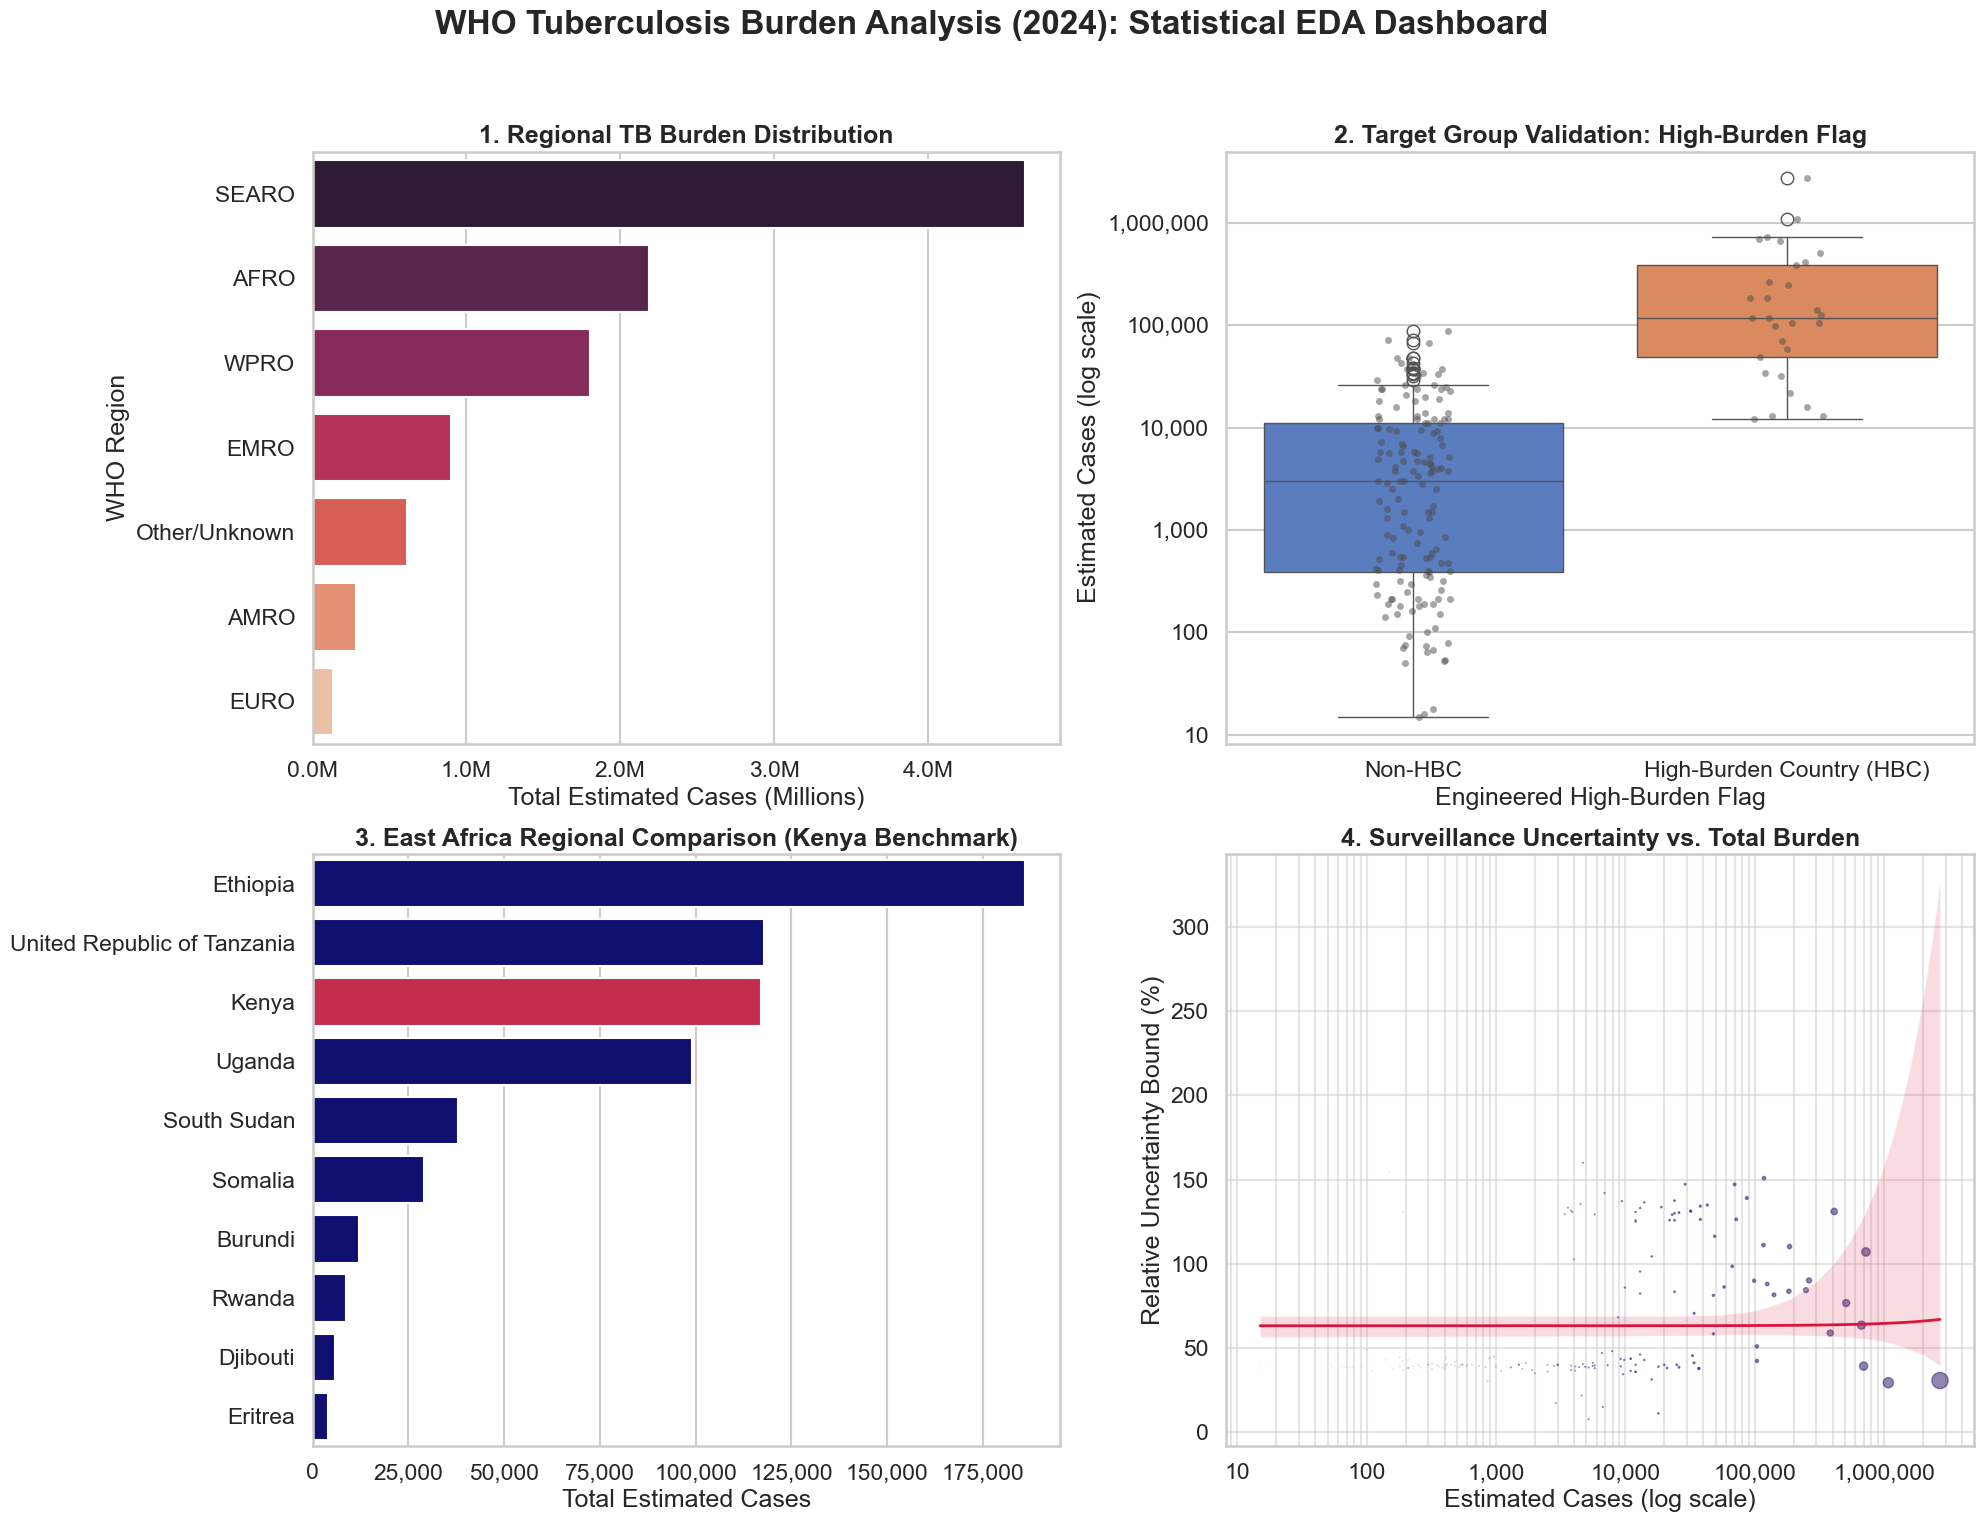

In [3]:

# Set global publication aesthetic
sns.set_theme(style="whitegrid", context="talk", palette="viridis", font="sans-serif")
plt.rcParams['font.size'] = 12

# 1. Ingest clean data directly from your optimized SQL view
df_base = pd.read_sql("SELECT * FROM vw_tb_country_totals;", con=engine)
df_eng = pd.read_sql("SELECT * FROM tb_burden_2024_engineered;", con=engine)

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle("WHO Tuberculosis Burden Analysis (2024): Statistical EDA Dashboard", fontsize=24, fontweight="bold", y=0.98)

# ----------------------------------------------------------------------------
# PLOT 1: Regional Burden & High Burden Density (AFRO/SEARO focus)
# ----------------------------------------------------------------------------
# FIX 1: Aggregate by region first so palette length matches unique regions exactly
df_region_agg = df_base.groupby("who_region")["total_cases"].sum().reset_index()
df_region_agg = df_region_agg.sort_values(by="total_cases", ascending=False)

ax1 = axes[0, 0]
sns.barplot(
    data=df_region_agg, 
    x="total_cases", 
    y="who_region", 
    ax=ax1, 
    palette="rocket", 
    hue="who_region", 
    legend=False
)
ax1.set_title("1. Regional TB Burden Distribution", fontweight="bold")
ax1.set_xlabel("Total Estimated Cases (Millions)")
ax1.set_ylabel("WHO Region")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))


# ----------------------------------------------------------------------------
# PLOT 2: Validating High-Burden Targeting (Statistical Grouping)
# ----------------------------------------------------------------------------
ax2 = axes[0, 1]
sns.boxplot(
    data=df_base, 
    x="high_burden_flag", 
    y="total_cases", 
    ax=ax2, 
    palette="muted", 
    hue="high_burden_flag", 
    legend=False
)
sns.stripplot(data=df_base, x="high_burden_flag", y="total_cases", ax=ax2, color="0.3", alpha=0.5, size=5)

ax2.set_title("2. Target Group Validation: High-Burden Flag", fontweight="bold")
ax2.set_xlabel("Engineered High-Burden Flag")
ax2.set_ylabel("Estimated Cases (log scale)")

# FIX 2: Set ticks explicitly before defining custom tick labels
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Non-HBC", "High-Burden Country (HBC)"])

# Log scale to account for extreme skew
ax2.set_yscale('log')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:,.0f}'.format(y)))


# ----------------------------------------------------------------------------
# PLOT 3: East Africa Regional Benchmarking (Kenya Focus)
# ----------------------------------------------------------------------------
df_ea = df_base[df_base['east_africa_flag'] == 1].sort_values(by="total_cases", ascending=False)
colors = ['crimson' if c == 'Kenya' else 'navy' for c in df_ea['country']]

ax3 = axes[1, 0]
sns.barplot(data=df_ea, x="total_cases", y="country", ax=ax3, palette=colors, hue="country", legend=False)
ax3.set_title("3. East Africa Regional Comparison (Kenya Benchmark)", fontweight="bold")
ax3.set_xlabel("Total Estimated Cases")
ax3.set_ylabel("")
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))


# ----------------------------------------------------------------------------
# PLOT 4: Uncertainty vs. Case Volume (Surveillance Capacity)
# ----------------------------------------------------------------------------
ax4 = axes[1, 1]
# FIX 3: Removed `robust=True` parameter to run standard linear regression without statsmodels dependency
sns.regplot(
    data=df_base, 
    x="total_cases", 
    y="ci_relative_width", 
    ax=ax4, 
    scatter_kws={'alpha':0.6, 's': df_base['total_cases']/20000},
    line_kws={'color':'crimson', 'lw':2}
)

ax4.set_title("4. Surveillance Uncertainty vs. Total Burden", fontweight="bold")
ax4.set_xlabel("Estimated Cases (log scale)")
ax4.set_ylabel("Relative Uncertainty Bound (%)")

ax4.set_xscale('log')
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))
ax4.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Observation

Plot 1 (Regional Breakdown): The dark-to-light rocket palette clearly draws immediate visual focus to SEARO (>4.5M) and AFRO (>2.0M), illustrating where global attention belongs.

Plot 2 (Target Group Boxplot): The separation between Non-HBC and High-Burden Countries on the log scale is distinct. The jittered strip points show the heavy concentration of small-burden nations vs. the tight cluster of HBC nations.

Plot 3 (East Africa Benchmark): The custom crimson highlighting on Kenya makes the comparison against Ethiopia, Tanzania, and Uganda pop instantly.

Plot 4 (Surveillance Uncertainty): Because log-scale regression without robust=True can cause standard linear trendlines to flare out at extreme values (notice the wide red confidence band on the far right around 1,000,000+ cases), it actually visually demonstrates why non-parametric statistics (like Spearman $\rho$) were necessary!

## 📊 Phase 3: Visual Exploratory Data Analysis & Dashboarding

A 4-panel publication-grade dashboard was engineered in Python (`seaborn` and `matplotlib`) to visually synthesize the statistical findings and spatial variations of the 2024 WHO Tuberculosis dataset.

### Executive Visual Summary:

1. **Regional Concentration (Plot 1):** South-East Asia (SEARO) and Africa (AFRO) dominate global tuberculosis incidence, accounting for over 6.5 million combined estimated cases.
2. **HBC Feature Validation (Plot 2):** Logarithmic scale boxplots validate that the engineered binary `high_burden_flag` isolates a stochastically distinct tier of high-volume target nations ($p < 0.0001$).
3. **East Africa Regional Benchmark (Plot 3):** Kenya ranks **3rd in the East African Community (EAC)** with ~117,000 estimated cases, trailing Ethiopia (~186,000) and Tanzania (~118,000).
4. **Surveillance Capacity & Variance (Plot 4):** Regression scatter plotting illustrates variance expansion at higher case volumes, matching our Spearman Rank correlation finding ($\rho = 0.4377$) regarding surveillance measurement uncertainty in high-burden health systems.